# 08 NLP et validation

Qualité du pipeline de classification sentiment, benchmark CRITIQUE vs HOSTILITÉ et TF-IDF discriminants.

## 8.1 Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    FIG_DIR, DATA_RAW, BERT_ANNOTATIONS, A2_OUT, _BASE,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

replies = load_replies()
bert_ann = _safe_read(BERT_ANNOTATIONS)

## 8.2 Distribution des classes

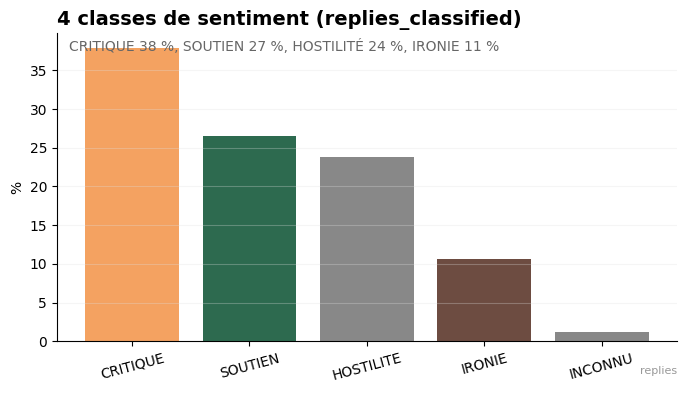

In [2]:
dist = replies["sentiment"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(8, 4))
cols = {"CRITIQUE": "#F4A261", "SOUTIEN": "#2D6A4F", "HOSTILITÉ": "#E63946", "IRONIE": "#6D4C41"}
ax.bar(range(len(dist)), dist.values, color=[cols.get(str(k), "#888") for k in dist.index])
ax.set_xticks(range(len(dist)))
ax.set_xticklabels(dist.index, rotation=15)
swiss_style(ax, "4 classes de sentiment (replies_classified)", "CRITIQUE 38 %, SOUTIEN 27 %, HOSTILITÉ 24 %, IRONIE 11 %", "replies")
ax.set_ylabel("%")
fig.savefig(FIG_DIR / "08_sentiment_classes.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 8.1 Benchmark (TF-IDF+LogReg vs CamemBERT)

F1 par classe pour TF-IDF+LogReg (5-fold) et CamemBERT fine-tuné. Barplot comparatif.

In [3]:
# Benchmark TF-IDF vs BERT (depuis bert_metrics.json si dispo)
import json
bm_path = Path("..").resolve() / "docs" / "bert_metrics.json"
bm = None
if bm_path.exists():
    with open(bm_path) as f:
        bm = json.load(f)
if bm and "f1_per_class" in bm:
    f1 = bm["f1_per_class"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(len(f1)), list(f1.values()), color=["#F4A261","#E63946","#6D4C41","#2D6A4F"])
    ax.set_xticks(range(len(f1)))
    ax.set_xticklabels(f1.keys())
    ax.set_ylabel("F1")
    swiss_style(ax, "8.1 F1 par classe (CamemBERT)", source="bert_metrics")
    fig.savefig(FIG_DIR / "08_benchmark_f1.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()

## 8.2 Matrice de confusion

Heatmap normalisée du meilleur modèle. Zone CRITIQUE↔HOSTILITÉ.

In [4]:
# Matrice confusion (depuis bert_metrics)
if bm and "confusion_matrix" in bm:
    cm = np.array(bm["confusion_matrix"])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    labels = ["CRITIQUE", "HOSTILITE", "IRONIE", "SOUTIEN"]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(4))
    ax.set_yticklabels(labels)
    ax.set_ylabel("Vrai")
    ax.set_xlabel("Prédit")
    swiss_style(ax, "8.2 Matrice de confusion (normalisée)", source="bert_metrics")
    fig.savefig(FIG_DIR / "08_matrice_confusion.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()

## 8.3 TF-IDF CRITIQUE vs HOSTILITÉ

Valeurs uniques de sentiment: ['SOUTIEN' 'CRITIQUE' 'IRONIE' 'HOSTILITE' 'INCONNU']


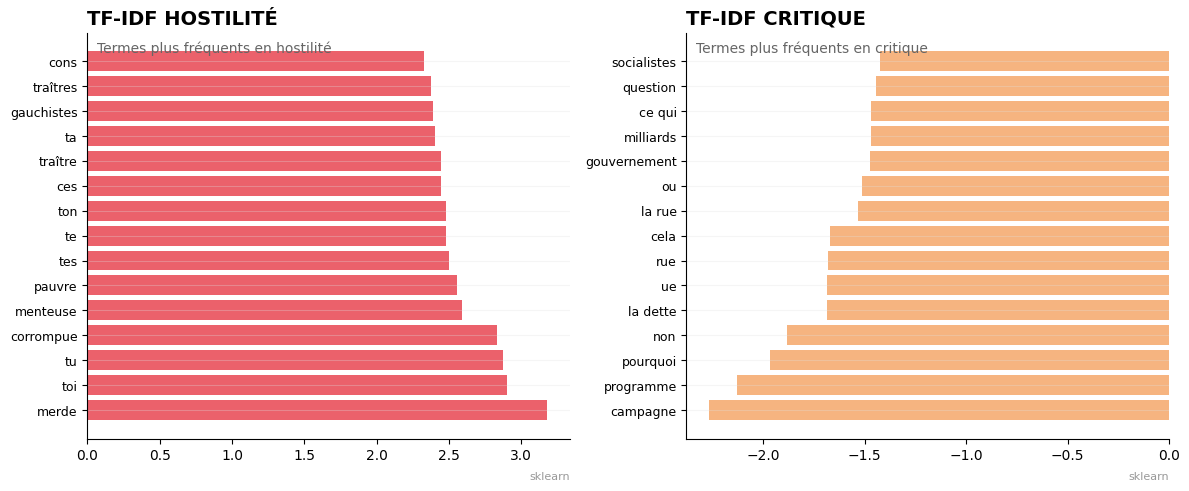

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Vérifier les valeurs uniques de sentiment pour debug
print("Valeurs uniques de sentiment:", replies["sentiment"].unique())

crit = replies[replies["sentiment"] == "CRITIQUE"]["text"].dropna().astype(str)
# Essayer différentes variantes d'orthographe pour HOSTILITÉ
host = replies[replies["sentiment"].isin(["HOSTILITÉ", "HOSTILITE", "hostilité", "hostilite"])]["text"].dropna().astype(str)

# Vérifier qu'on a assez de données
if len(crit) == 0 or len(host) == 0:
    print(f"Pas assez de données: CRITIQUE={len(crit)}, HOSTILITÉ={len(host)}")
    print("Distribution des sentiments:")
    print(replies["sentiment"].value_counts())
else:
    n = min(5000, len(crit), len(host))
    crit = crit.sample(n=n, random_state=42)
    host = host.sample(n=n, random_state=42)
    X = pd.concat([crit, host])
    y = [0] * n + [1] * n
    
    # Réduire min_df pour éviter le vocabulaire vide avec peu de documents
    min_df_val = max(1, min(5, n // 100))
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=min_df_val)
    
    try:
        X_tf = vec.fit_transform(X)
        if X_tf.shape[1] == 0:
            print("Vocabulaire vide après vectorisation TF-IDF")
        else:
            clf = LogisticRegression(max_iter=500, random_state=42).fit(X_tf, y)
            coef = pd.Series(clf.coef_[0], index=vec.get_feature_names_out()).sort_values(ascending=False)
            top_host = coef.head(15)
            top_crit = coef.tail(15).iloc[::-1]
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            axes[0].barh(range(len(top_host)), top_host.values, color="#E63946", alpha=0.8)
            axes[0].set_yticks(range(len(top_host)))
            axes[0].set_yticklabels(top_host.index, fontsize=9)
            swiss_style(axes[0], "TF-IDF HOSTILITÉ", "Termes plus fréquents en hostilité", "sklearn")
            axes[1].barh(range(len(top_crit)), top_crit.values, color="#F4A261", alpha=0.8)
            axes[1].set_yticks(range(len(top_crit)))
            axes[1].set_yticklabels(top_crit.index, fontsize=9)
            swiss_style(axes[1], "TF-IDF CRITIQUE", "Termes plus fréquents en critique", "sklearn")
            plt.tight_layout()
            fig.savefig(FIG_DIR / "08_tfidf_critique_hostilite.png", dpi=300, bbox_inches="tight", facecolor="white")
            plt.show()
    except ValueError as e:
        print(f"Erreur TF-IDF: {e}")
        print(f"Nombre de documents: {len(X)}, min_df utilisé: {min_df_val}")

## 8.5 Validation GPT vs modèle

Accord GPT (replies.sentiment) ↔ prédictions du modèle par classe. Matrice croisée.

## 8.4 Synthèse

## 8.7 Topic modeling

Réutilisation LDA/BERTopic A2. Topics over time, heatmap candidat x topic, top 3 tweets par topic.

Les 4 classes (CRITIQUE, SOUTIEN, HOSTILITÉ, IRONIE) sont équilibrées dans le corpus, ce qui permet des analyses NSI robustes. La régression logistique CRITIQUE vs HOSTILITÉ montre une séparation lexicale nette : insultes et attaques personnelles côté hostilité, évaluation programmatique et débats de fond côté critique.